Loading:   0%|          | 0/5 [00:00<?, ?it/s]

Battery sizes:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

...

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

Power configs:   0%|          | 0/5 [00:00<?, ?it/s]

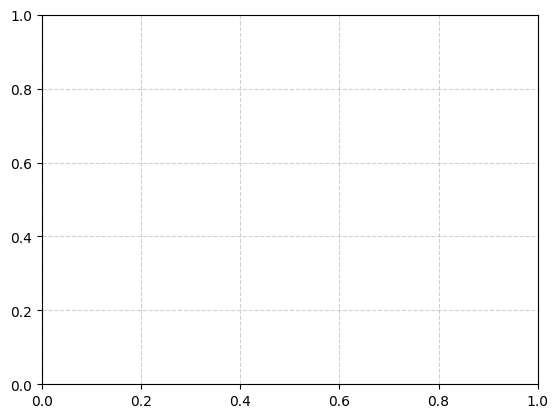

In [1]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.grid(True, linestyle='--', alpha=0.6)

########################################################   CONSTANTS   ########################################################
SunPower = 1361                                     # Raw power of sunlight when it reaches the satellite in W/m2
BOLSolarCellEfficiency = 0.3                        # Beginning Of Life efficiency of the Solar Cells
EOLSolarCellEfficiency = 0.209                      # End Of Life efficiency of the Solar Cells
BatteryDegradationFittingConstant = 0.0000348       # Curve fitting constant in s^-1/2

####################################################   ITERATING CONSTANTS   ##################################################
# Each value is defined as: value = [minimum, maximum, step]
PanelSurface = [3, 5, 0.4]                          # Effective surface of the Solar Panels (just the surface of the cells)
BOLBatteryCapacity = [600, 1200, 120]                # Initial capacity of the battery in Wh
PowerDraw = [600, 1000, 80]                         # Power drawn by the system 

#######################################################   MAIN PROGRAM   ######################################################
# Import data from csv files
SolarIntensity = pd.read_csv('Solar_intensity.csv')['Intensity']
SunVector = pd.read_csv('sun_vector.csv')[['x (km)', 'y (km)', 'z (km)']]

# Check if the files match dates and times
Times = pd.read_csv('Solar_intensity.csv')[['Time (UTCG)']]
Times = Times.rename(columns={'Time (UTCG)': 'Solar Intensity'})
Times['Sun Vector'] = pd.read_csv('sun_vector.csv')['Time (UTCG)']
Times['Solar Intensity'] = pd.to_datetime(Times['Solar Intensity'])
Times['Sun Vector'] = pd.to_datetime(Times['Sun Vector'])
if (Times['Sun Vector'] != Times['Solar Intensity']).any():
    if len(Times['Sun Vector']) != len(Times['Solar Intensity']):
        raise ValueError('>>> ERROR: Files have different number of rows. Files may be from different simulations')
    else:
        raise ValueError('>>> ERROR: Timestamps are not the same between files. Files may be from different simulations')
    
# Create a timestep for the calculations
Times['Timestep'] = Times['Solar Intensity'].diff().dt.total_seconds().fillna(0)
Times['CumulativeTime'] = Times['Timestep'].cumsum()

# Calculate angles of incidence from each plane
SunVector['X Face Angle'] = np.arcsin(SunVector['x (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2))))
SunVector['Y Face Angle'] = np.arcsin(SunVector['y (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2))))
SunVector['Z Face Angle'] = np.arcsin(SunVector['z (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2))))

# Calculate efficiency of the Solar Cells for the duration of the mission
PanelEfficiency = pd.Series(np.linspace(BOLSolarCellEfficiency, EOLSolarCellEfficiency, num = len(Times['Sun Vector'])))

# Define lists of pandas df's for each iteration
Generation = []
Battery = []

# Iterate for every panel surface
for PanelSurfaceIndex in range(int((PanelSurface[1] - PanelSurface[0]) / PanelSurface[2])):
    IterationPanelSurface = PanelSurface[0] + (PanelSurface[2] * PanelSurfaceIndex)

    # Calculate the power generation from each satellite face
    Generation.append(pd.DataFrame())
    Generation[PanelSurfaceIndex]['W generated in face X'] = SunPower * np.sin(SunVector['X Face Angle']) * PanelEfficiency * IterationPanelSurface * SolarIntensity
    Generation[PanelSurfaceIndex]['W generated in face Y'] = SunPower * np.sin(SunVector['Y Face Angle']) * PanelEfficiency * IterationPanelSurface * SolarIntensity
    Generation[PanelSurfaceIndex]['W generated in face Z'] = SunPower * np.sin(SunVector['Z Face Angle']) * PanelEfficiency * IterationPanelSurface * SolarIntensity

# Iterate for every BOL Battery Capacity
for BOLBatteryCapacityIndex in range(int((BOLBatteryCapacity[1] - BOLBatteryCapacity[0]) / BOLBatteryCapacity[2])):
    IterationBOLBatteryCapacity = BOLBatteryCapacity[0] + (BOLBatteryCapacity[2] * BOLBatteryCapacityIndex)

    # Calculate the degradation of the battery in each point in time
    Battery.append(pd.DataFrame())
    Battery[BOLBatteryCapacityIndex]['TotalCapacity'] = IterationBOLBatteryCapacity * (1 - (BatteryDegradationFittingConstant * np.sqrt(Times['CumulativeTime'])))

# Iterate every value to calculate charge
for PanelSurfaceIndex in tqdm(range(int((PanelSurface[1] - PanelSurface[0]) / PanelSurface[2])), desc='Loading'):
    IterationPanelSurface = PanelSurface[0] + (PanelSurface[2] * PanelSurfaceIndex)

    for BOLBatteryCapacityIndex in tqdm(range(int((BOLBatteryCapacity[1] - BOLBatteryCapacity[0]) / BOLBatteryCapacity[2])), desc='Battery sizes', leave=False):
        IterationBOLBatteryCapacity = BOLBatteryCapacity[0] + (BOLBatteryCapacity[2] * BOLBatteryCapacityIndex)

        for PowerDrawIndex in tqdm(range(int((PowerDraw[1] - PowerDraw[0]) / PowerDraw[2])), desc='Power configs', leave=False):
            IterationPowerDraw = PowerDraw[0] + (PowerDraw[2] * PowerDrawIndex)

            # Calculate state of charge of the battery in each point in time
            Battery[BOLBatteryCapacityIndex]['Charge'] = np.nan
            Battery[BOLBatteryCapacityIndex].loc[0, 'Charge'] = IterationBOLBatteryCapacity
            OutOfBattery = 0
            for i in range(len(Battery[BOLBatteryCapacityIndex]['Charge'])-1):
                NextValue = Battery[BOLBatteryCapacityIndex]['Charge'].iloc[i] + (((Generation[PanelSurfaceIndex]['W generated in face Y'][i+1] - IterationPowerDraw) * Times['Timestep'][1])/3600)
                if NextValue > Battery[BOLBatteryCapacityIndex]['TotalCapacity'].iloc[i+1]:
                    Battery[BOLBatteryCapacityIndex].loc[i+1, 'Charge'] = Battery[BOLBatteryCapacityIndex]['TotalCapacity'].iloc[i+1]
                elif NextValue < 0:
                    Battery[BOLBatteryCapacityIndex].loc[i+1, 'Charge'] = 0
                    OutOfBattery = 1
                else:
                    Battery[BOLBatteryCapacityIndex].loc[i+1, 'Charge'] = NextValue

In [ ]:
from matplotlib import cm

ax = plt.axes(projection='3d')
ax.plot_surface(x,y,z, cmap = cm.coolwarm, linewidth=0, antialiased=False)
ax.plot_surface(x, Times['Sun Vector'], Battery['Charge'])
plt.show()
